IEEE Fraud Detection: Comprehensive EDA and Preprocessing Pipeline
==================================================================

Project Overview
----------------

This project performs comprehensive Exploratory Data Analysis (EDA) and data preprocessing for the IEEE-CIS Fraud Detection dataset from Kaggle. The pipeline includes advanced techniques for handling missing values, detecting outliers, treating skewness, and feature engineering.

* * * * *

In [1]:
%pip install --upgrade scikit-learn imbalanced-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 92.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 15.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sklearn
print(f"scikit-learn: {sklearn.__version__}")

scikit-learn: 1.7.2


In [5]:
"""
IEEE Fraud Detection: Enhanced EDA and Preprocessing Pipeline
Focus on ProductCD and Important Features | Separate Train/Test Processing
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import torch
from imblearn.over_sampling import ADASYN
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.utils import resample  
from collections import Counter
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split ,  learning_curve
import xgboost as xgb
import joblib  
from sklearn.preprocessing import label_binarize 
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [6]:
# Check if GPU is available (Kaggle GPU)
if tf.config.list_physical_devices('GPU'):
    print("GPU DETECTED: TensorFlow sees Kaggle GPU ✓")
    print(f"   GPU Device: {tf.config.list_physical_devices('GPU')}")
else:
    print("No GPU detected by TensorFlow")

GPU DETECTED: TensorFlow sees Kaggle GPU ✓
   GPU Device: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


1\. Data Loading and Initial Setup
----------------------------------

Purpose: Load all required datasets and handle any file loading errors gracefully.

In [7]:
print("="*80)
print("IEEE FRAUD DETECTION - FOCUSED EDA & PREPROCESSING")
print("="*80)

# Load datasets
print("\n[1] Loading datasets...")
train_transaction = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_identity.csv')
test_transaction = pd.read_csv('/kaggle/input/ieee-fraud-detection/test_transaction.csv')
test_identity = pd.read_csv('/kaggle/input/ieee-fraud-detection/test_identity.csv')
df_sample = pd.read_csv('/kaggle/input/ieee-fraud-detection/sample_submission.csv')

IEEE FRAUD DETECTION - FOCUSED EDA & PREPROCESSING

[1] Loading datasets...


2\. Data Merging and Column Alignment
-------------------------------------

Purpose: Merge transaction and identity data, then align columns between training and test sets to ensure consistency.


In [8]:
print("\n[2] Merging and aligning train/test datasets...")

# Merge transaction and identity data
train = train_transaction.merge(train_identity, on='TransactionID', how='left')
test = test_transaction.merge(test_identity, on='TransactionID', how='left')

print(f"Original train shape: {train.shape}")
print(f"Original test shape: {test.shape}")

# Align columns between train and test (critical step)
common_cols = list(set(train.columns) & set(test.columns))
train = train[common_cols + ['isFraud']]  # Ensure target is included
test = test[common_cols]

print(f"Aligned train shape: {train.shape}")
print(f"Aligned test shape: {test.shape}")
print(f"Common features: {len(common_cols)}")


[2] Merging and aligning train/test datasets...
Original train shape: (590540, 434)
Original test shape: (506691, 433)
Aligned train shape: (590540, 396)
Aligned test shape: (506691, 395)
Common features: 395


In [9]:
print("DUPLICATES CHECK & REMOVAL")

print(f"Train Transaction duplicates before merge: {train_transaction.duplicated().sum()}")
print(f"Train Identity duplicates before merge: {train_identity.duplicated().sum()}")

initial_shape = train.shape[0]
duplicates = train.duplicated().sum()

print(f"\nAfter merging train_transaction + train_identity:")
print(f"   Total rows: {initial_shape:,}")
print(f"   Duplicate rows found: {duplicates:,}")

if duplicates > 0:
    train = train.drop_duplicates(keep='first')
    print(f"   Duplicates removed → New shape: {train.shape}")
else:
    print("   No duplicate rows found → Data is clean ✓")

print("Preprocessing Step: Handling Duplicates → COMPLETED ✓")

DUPLICATES CHECK & REMOVAL
Train Transaction duplicates before merge: 0
Train Identity duplicates before merge: 0

After merging train_transaction + train_identity:
   Total rows: 590,540
   Duplicate rows found: 0
   No duplicate rows found → Data is clean ✓
Preprocessing Step: Handling Duplicates → COMPLETED ✓


3\. Comprehensive Data Overview
-------------------------------

Purpose: Provide high-level statistics about the dataset including target distribution, data types, and class imbalance analysis.

In [10]:
print("\n" + "="*80)
print("COMPREHENSIVE DATA OVERVIEW")
print("="*80)

print("\n[Dataset Information]")
print(f"Total features: {train.shape[1]}")
print(f"Training samples: {train.shape[0]:,}")
print(f"Test samples: {test.shape[0]:,}")

print("\n[Target Distribution Analysis]")
fraud_counts = train['isFraud'].value_counts()
fraud_percentage = train['isFraud'].value_counts(normalize=True) * 100
print(f"Non-Fraud (0): {fraud_counts[0]:,} ({fraud_percentage[0]:.2f}%)")
print(f"Fraud (1): {fraud_counts[1]:,} ({fraud_percentage[1]:.2f}%)")
print(f"Class Imbalance Ratio: {fraud_counts[0]/fraud_counts[1]:.2f}:1")

print("\n[Data Types Summary]")
dtype_summary = train.dtypes.value_counts()
for dtype, count in dtype_summary.items():
    print(f"  {dtype}: {count} features")


COMPREHENSIVE DATA OVERVIEW

[Dataset Information]
Total features: 396
Training samples: 590,540
Test samples: 506,691

[Target Distribution Analysis]
Non-Fraud (0): 569,877 (96.50%)
Fraud (1): 20,663 (3.50%)
Class Imbalance Ratio: 27.58:1

[Data Types Summary]
  float64: 376 features
  object: 16 features
  int64: 4 features


4\. Advanced Missing Value Analysis
-----------------------------------

Purpose: Perform detailed analysis of missing values including distribution statistics and identification of features with high missing percentages.

In [11]:
print("\n" + "="*80)
print("ADVANCED MISSING VALUE ANALYSIS")
print("="*80)

def comprehensive_missing_analysis(df, name):
    """Enhanced missing value analysis with statistics"""
    missing = df.isnull().sum()
    missing_pct = 100 * missing / len(df)
    missing_table = pd.DataFrame({
        'Missing_Count': missing,
        'Percentage': missing_pct
    })
    missing_table = missing_table[missing_table['Missing_Count'] > 0].sort_values(
        'Percentage', ascending=False
    )
    
    print(f"\n[{name} Missing Analysis]")
    print(f"Features with missing values: {len(missing_table)}")
    print(f"Total missing cells: {missing.sum():,}")
    print(f"Overall missing percentage: {(missing.sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")
    
    # Missing value distribution statistics
    print(f"\nMissing Value Distribution:")
    print(f"  >80% missing: {len(missing_table[missing_table['Percentage'] > 80])} features")
    print(f"  50-80% missing: {len(missing_table[(missing_table['Percentage'] >= 50) & (missing_table['Percentage'] <= 80)])} features")
    print(f"  20-50% missing: {len(missing_table[(missing_table['Percentage'] >= 20) & (missing_table['Percentage'] < 50)])} features")
    print(f"  <20% missing: {len(missing_table[missing_table['Percentage'] < 20])} features")
    
    return missing_table

train_missing = comprehensive_missing_analysis(train, "Training Set")
test_missing = comprehensive_missing_analysis(test, "Test Set")

print("\n[Top 15 Features with Most Missing Values]")
print(train_missing.head(15))


ADVANCED MISSING VALUE ANALYSIS

[Training Set Missing Analysis]
Features with missing values: 376
Total missing cells: 96,488,290
Overall missing percentage: 41.26%

Missing Value Distribution:
  >80% missing: 55 features
  50-80% missing: 121 features
  20-50% missing: 38 features
  <20% missing: 162 features

[Test Set Missing Analysis]
Features with missing values: 347
Total missing cells: 74,251,557
Overall missing percentage: 37.10%

Missing Value Distribution:
  >80% missing: 52 features
  50-80% missing: 120 features
  20-50% missing: 23 features
  <20% missing: 152 features

[Top 15 Features with Most Missing Values]
       Missing_Count  Percentage
dist2         552913   93.628374
D7            551623   93.409930
D13           528588   89.509263
D14           528353   89.469469
D12           525823   89.041047
D6            517353   87.606767
D9            515614   87.312290
D8            515614   87.312290
V138          508595   86.123717
V147          508595   86.123717
V1

5\. Missing Values Visualization
--------------------------------

Purpose: Create comprehensive visualizations to understand missing value patterns across features and samples.


[3] Visualizing missing value patterns...


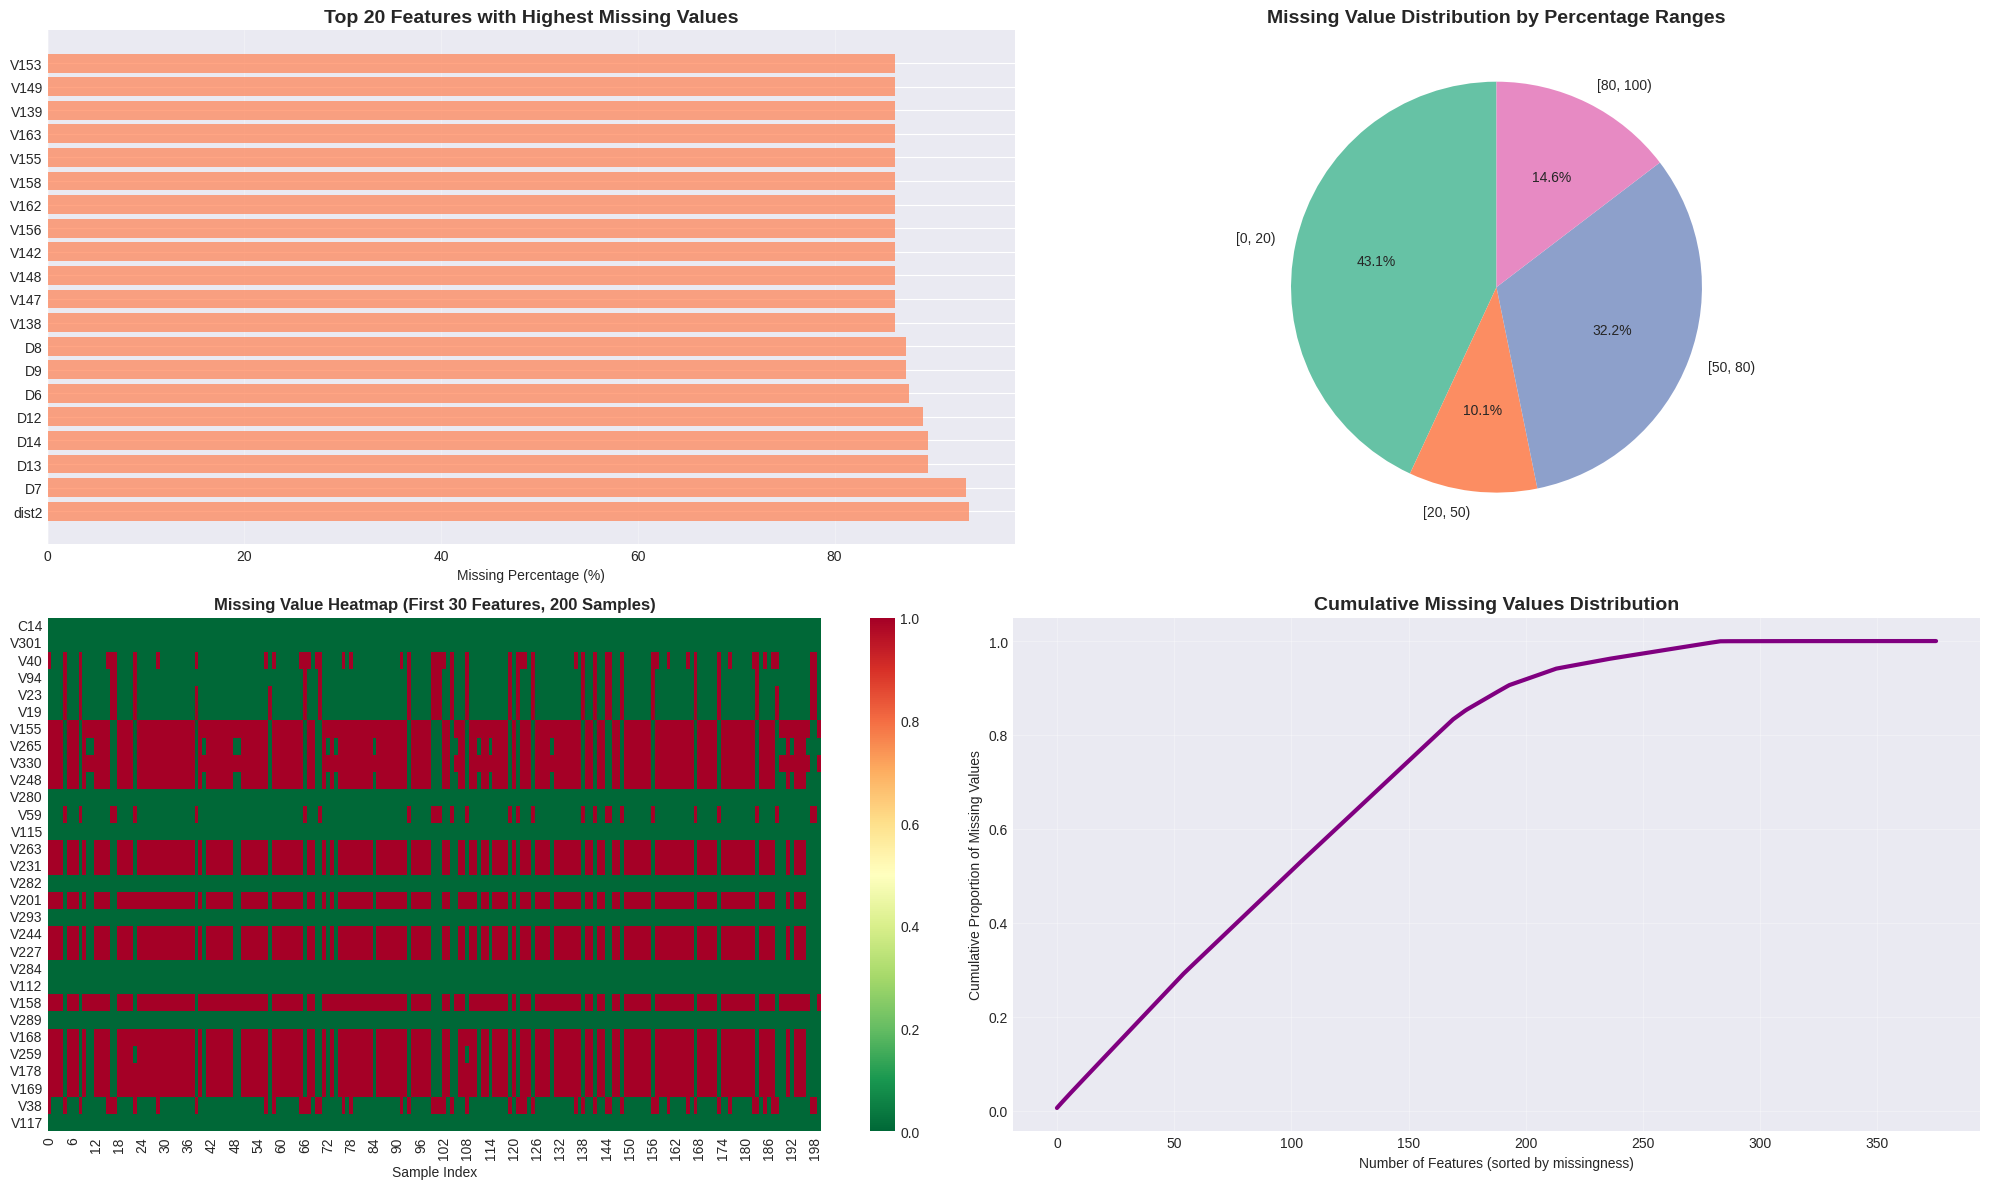

In [12]:
print("\n[3] Visualizing missing value patterns...")

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Missing values by percentage (top 20)
top_missing = train_missing.head(20)
axes[0, 0].barh(range(len(top_missing)), top_missing['Percentage'], color='coral', alpha=0.7)
axes[0, 0].set_yticks(range(len(top_missing)))
axes[0, 0].set_yticklabels(top_missing.index)
axes[0, 0].set_xlabel('Missing Percentage (%)')
axes[0, 0].set_title('Top 20 Features with Highest Missing Values', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Missing value distribution
bins = [0, 20, 50, 80, 100]
missing_ranges = pd.cut(train_missing['Percentage'], bins=bins, right=False)
range_counts = missing_ranges.value_counts().sort_index()
axes[0, 1].pie(range_counts.values, labels=range_counts.index.astype(str), 
               autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set2"))
axes[0, 1].set_title('Missing Value Distribution by Percentage Ranges', fontsize=14, fontweight='bold')

# Missing value heatmap for first 30 features
sample_cols = train.columns[:30]
missing_matrix = train[sample_cols].isnull().astype(int)
sns.heatmap(missing_matrix.head(200).T, cbar=True, cmap='RdYlGn_r', 
            ax=axes[1, 0], yticklabels=True)
axes[1, 0].set_title('Missing Value Heatmap (First 30 Features, 200 Samples)', 
                  fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Sample Index')

# Cumulative missing values
cumulative_missing = train_missing['Missing_Count'].cumsum() / train_missing['Missing_Count'].sum()
axes[1, 1].plot(range(len(cumulative_missing)), cumulative_missing, linewidth=3, color='purple')
axes[1, 1].set_xlabel('Number of Features (sorted by missingness)')
axes[1, 1].set_ylabel('Cumulative Proportion of Missing Values')
axes[1, 1].set_title('Cumulative Missing Values Distribution', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('01_advanced_missing_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

6\. Target Variable Deep Dive
-----------------------------

Purpose: Analyze the target variable distribution and its relationship with transaction amounts and time patterns.


TARGET VARIABLE DEEP DIVE ANALYSIS


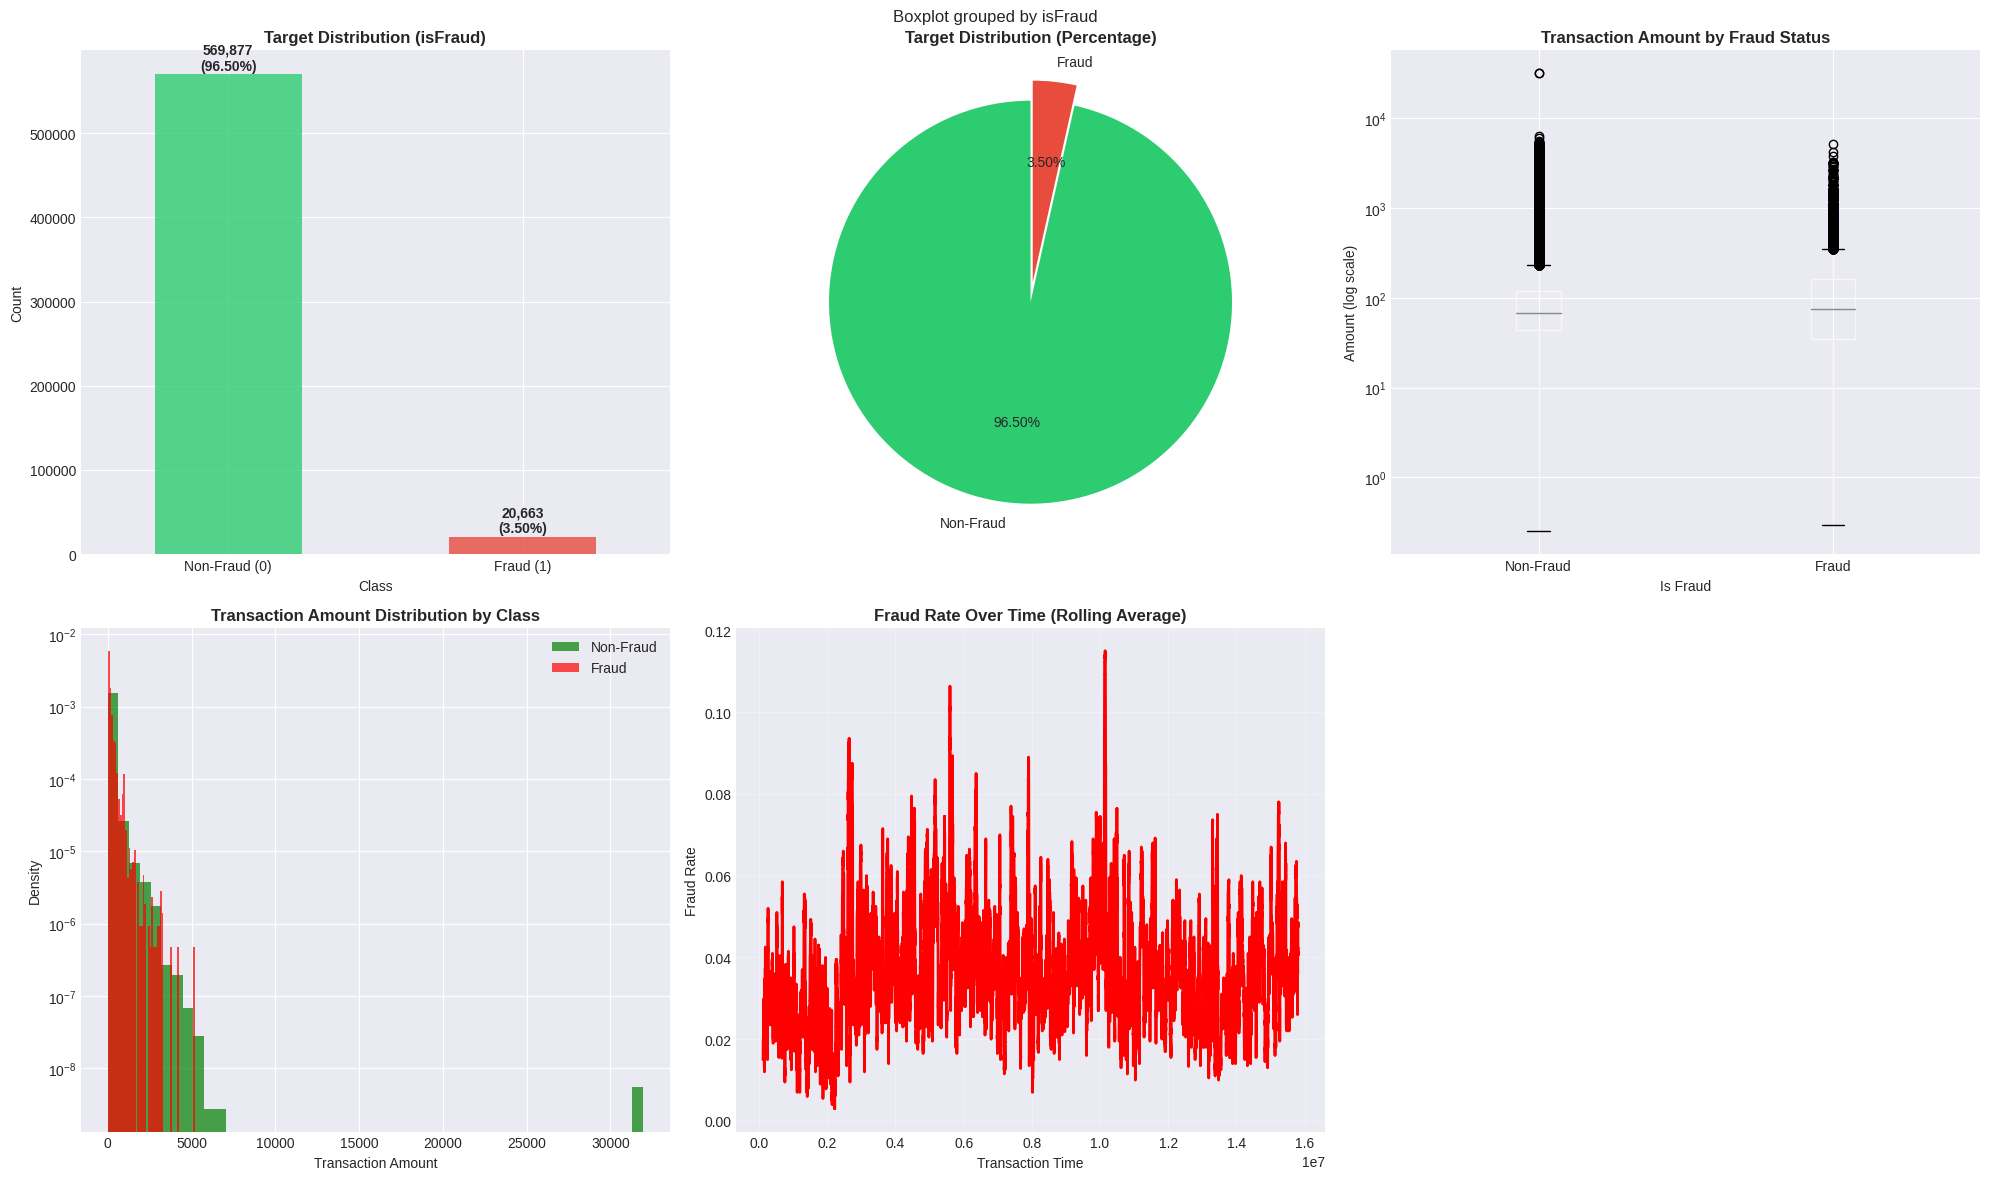

In [13]:
print("\n" + "="*80)
print("TARGET VARIABLE DEEP DIVE ANALYSIS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Target distribution bar chart
fraud_counts.plot(kind='bar', ax=axes[0, 0], color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0, 0].set_title('Target Distribution (isFraud)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xticklabels(['Non-Fraud (0)', 'Fraud (1)'], rotation=0)
for i, v in enumerate(fraud_counts):
    axes[0, 0].text(i, v + 5000, f'{v:,}\n({v/len(train)*100:.2f}%)', 
                   ha='center', fontweight='bold', fontsize=10)

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[0, 1].pie(fraud_counts, labels=['Non-Fraud', 'Fraud'], autopct='%1.2f%%',
              colors=colors, startangle=90, explode=(0, 0.1))
axes[0, 1].set_title('Target Distribution (Percentage)', fontsize=12, fontweight='bold')

# Transaction amount by fraud status (boxplot)
train.boxplot(column='TransactionAmt', by='isFraud', ax=axes[0, 2])
axes[0, 2].set_title('Transaction Amount by Fraud Status', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Is Fraud')
axes[0, 2].set_ylabel('Amount (log scale)')
axes[0, 2].set_yscale('log')
plt.sca(axes[0, 2])
plt.xticks([1, 2], ['Non-Fraud', 'Fraud'])

# Transaction amount distribution by fraud status
fraud_trans = train[train['isFraud'] == 1]['TransactionAmt']
non_fraud_trans = train[train['isFraud'] == 0]['TransactionAmt']

axes[1, 0].hist(non_fraud_trans, bins=50, alpha=0.7, label='Non-Fraud', color='green', density=True)
axes[1, 0].hist(fraud_trans, bins=50, alpha=0.7, label='Fraud', color='red', density=True)
axes[1, 0].set_title('Transaction Amount Distribution by Class', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Transaction Amount')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()
axes[1, 0].set_yscale('log')

# Time-based fraud pattern
if 'TransactionDT' in train.columns:
    time_fraud = train.groupby('TransactionDT')['isFraud'].agg(['sum', 'count'])
    time_fraud['fraud_rate'] = time_fraud['sum'] / time_fraud['count']
    axes[1, 1].plot(time_fraud.index, time_fraud['fraud_rate'].rolling(1000).mean(), 
                   color='red', linewidth=2)
    axes[1, 1].set_title('Fraud Rate Over Time (Rolling Average)', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Transaction Time')
    axes[1, 1].set_ylabel('Fraud Rate')
    axes[1, 1].grid(alpha=0.3)

# Remove empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('02_target_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

7\. Skewness and Outlier Analysis
---------------------------------

Purpose: Identify numerical features with high skewness and detect outliers using statistical methods.


In [14]:
print("\n" + "="*80)
print("SKEWNESS AND OUTLIER ANALYSIS")
print("="*80)

# Identify numerical columns
numerical_cols = train.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID and target
if 'TransactionID' in numerical_cols:
    numerical_cols.remove('TransactionID')
if 'isFraud' in numerical_cols:
    numerical_cols.remove('isFraud')

print(f"Analyzing {len(numerical_cols)} numerical features for skewness and outliers...")

# Calculate skewness and kurtosis
skewness_results = []
for col in numerical_cols[:50]:  # First 50 for performance
    if col in train.columns:
        skew_val = train[col].skew()
        kurt_val = train[col].kurtosis()
        
        # Outlier detection using IQR
        Q1 = train[col].quantile(0.25)
        Q3 = train[col].quantile(0.75)
        IQR = Q3 - Q1
        outlier_count = ((train[col] < (Q1 - 1.5 * IQR)) | (train[col] > (Q3 + 1.5 * IQR))).sum()
        outlier_pct = (outlier_count / len(train)) * 100
        
        skewness_results.append({
            'feature': col,
            'skewness': skew_val,
            'kurtosis': kurt_val,
            'outliers': outlier_count,
            'outlier_pct': outlier_pct
        })

skewness_df = pd.DataFrame(skewness_results)

print("\n[Top 10 Most Skewed Features]")
print(skewness_df.nlargest(10, 'skewness')[['feature', 'skewness', 'outlier_pct']])

print("\n[Top 10 Features with Most Outliers]")
print(skewness_df.nlargest(10, 'outlier_pct')[['feature', 'outlier_pct', 'skewness']])


SKEWNESS AND OUTLIER ANALYSIS
Analyzing 378 numerical features for skewness and outliers...

[Top 10 Most Skewed Features]
   feature   skewness  outlier_pct
19    V227  99.428666     2.197988
25    V259  60.747901     7.441156
13    V263  38.688826     5.443323
39    V254  36.527599     0.581502
9     V248  33.603353     0.825685
17    V293  30.582338     7.465371
35    V272  29.568807     2.197988
7     V265  28.091386     4.206150
48     C12  27.415129    17.160734
47    V130  26.295628    15.618248

[Top 10 Features with Most Outliers]
   feature  outlier_pct   skewness
36    V302    23.764182   2.802649
5      V19    18.424154  -0.877654
23    V289    17.305856   3.509881
48     C12    17.160734  27.415129
0      C14    16.271548  16.534887
47    V130    15.618248  26.295628
30     V92    12.306872   2.527127
3      V94    11.631388   2.111911
11     V59    10.974362   4.380069
2      V40    10.792495   6.645349


8\. Skewness and Outlier Visualization
--------------------------------------

Purpose: Visualize the distribution of skewness and outliers across features, and demonstrate transformation effects.


[4] Visualizing skewness and outlier patterns...


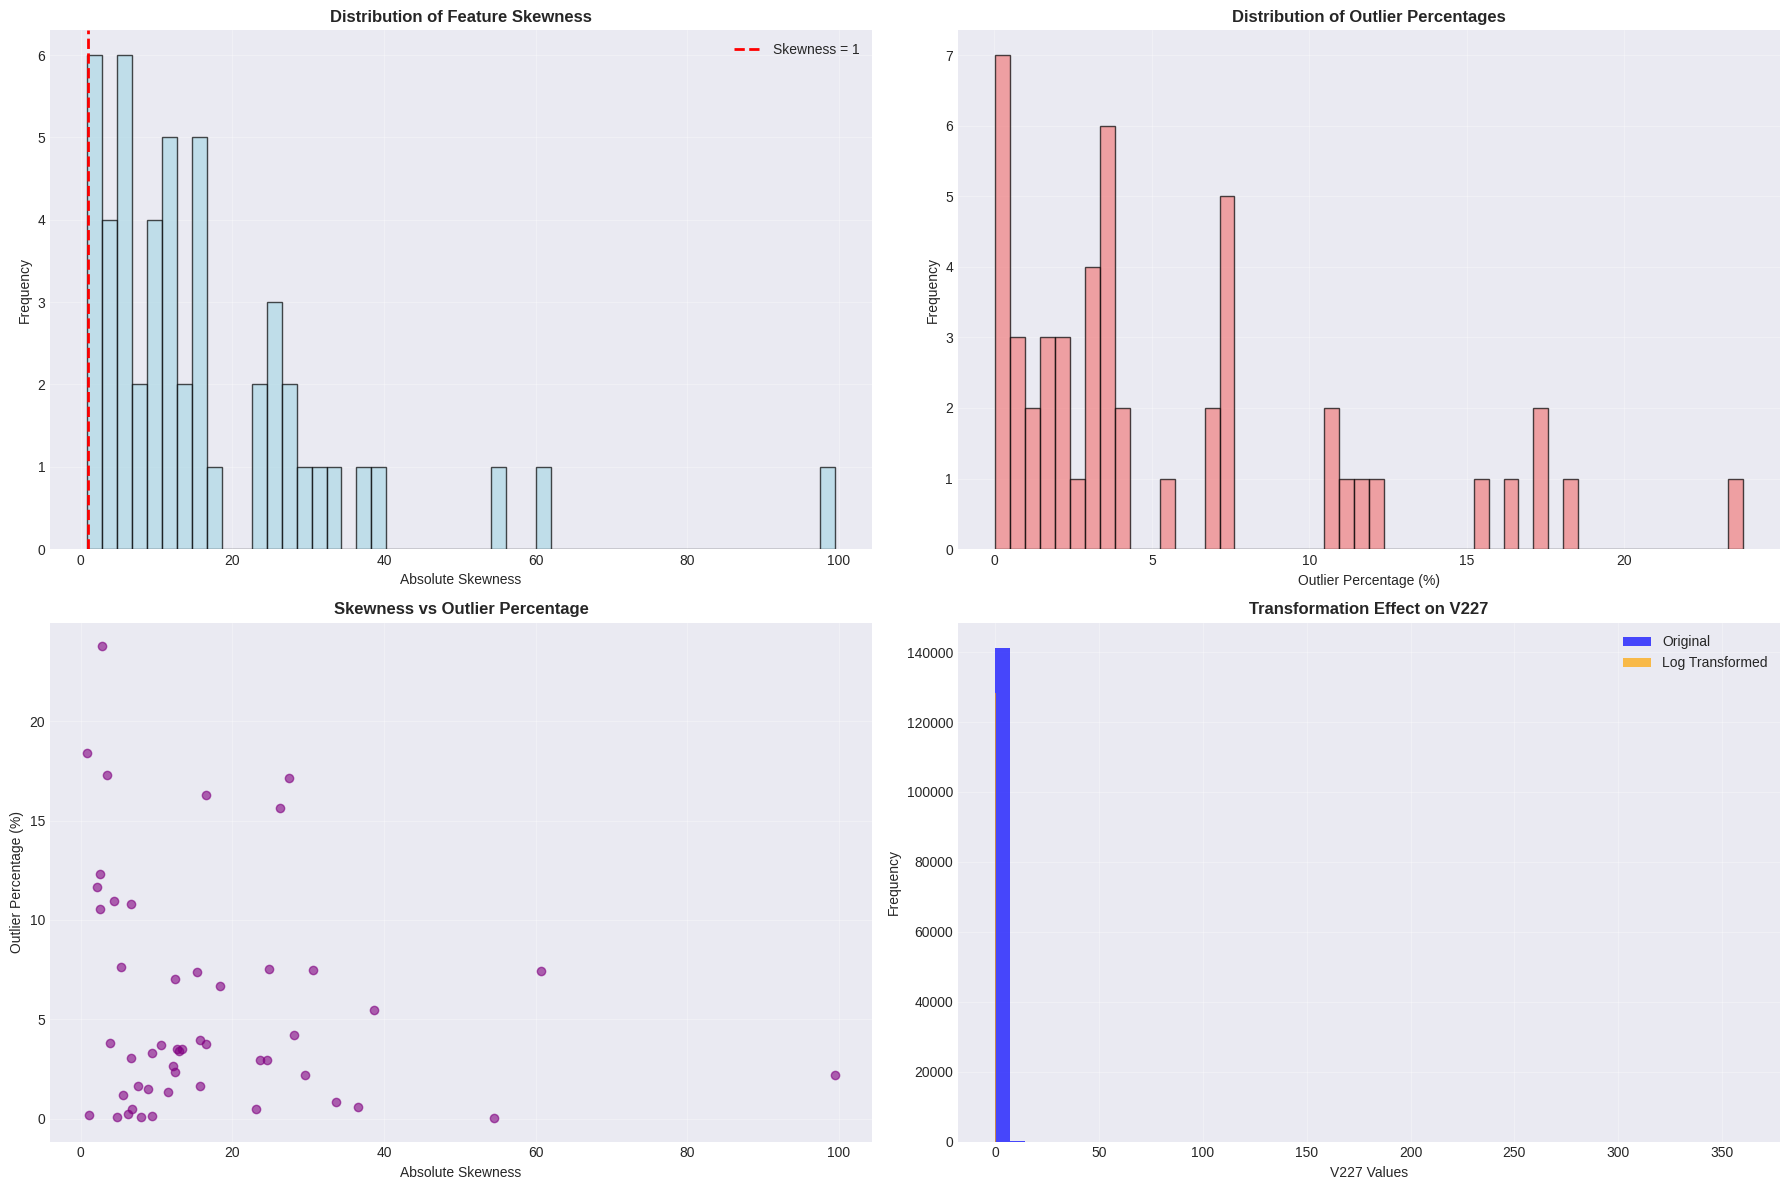

In [15]:
print("\n[4] Visualizing skewness and outlier patterns...")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Skewness distribution
axes[0, 0].hist(skewness_df['skewness'].abs(), bins=50, color='lightblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=1, color='red', linestyle='--', linewidth=2, label='Skewness = 1')
axes[0, 0].set_xlabel('Absolute Skewness')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Feature Skewness', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Outlier percentage distribution
axes[0, 1].hist(skewness_df['outlier_pct'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Outlier Percentage (%)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Outlier Percentages', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Skewness vs Outliers scatter plot
axes[1, 0].scatter(skewness_df['skewness'].abs(), skewness_df['outlier_pct'], 
                   alpha=0.6, color='purple')
axes[1, 0].set_xlabel('Absolute Skewness')
axes[1, 0].set_ylabel('Outlier Percentage (%)')
axes[1, 0].set_title('Skewness vs Outlier Percentage', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Top skewed features before/after transformation
top_skewed_feature = skewness_df.nlargest(1, 'skewness')['feature'].iloc[0]
if top_skewed_feature in train.columns:
    original_data = train[top_skewed_feature].dropna()
    
    # Apply log transformation
    transformed_data = np.log1p(np.abs(original_data))
    
    axes[1, 1].hist(original_data, bins=50, alpha=0.7, label='Original', color='blue')
    axes[1, 1].hist(transformed_data, bins=50, alpha=0.7, label='Log Transformed', color='orange')
    axes[1, 1].set_xlabel(f'{top_skewed_feature} Values')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title(f'Transformation Effect on {top_skewed_feature}', fontsize=12, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('03_skewness_outlier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

9\. Enhanced Data Preprocessing Class
-------------------------------------

Purpose: Implement a comprehensive preprocessing pipeline that handles missing values, encoding, feature engineering, and scaling with robust error handling.

In [16]:
print("\n" + "="*80)
print("ENHANCED DATA PREPROCESSING")
print("="*80)

class EnhancedFraudPreprocessor:
    def __init__(self, skew_threshold=1.0, missing_threshold=0.8):
        self.skew_threshold = skew_threshold
        self.missing_threshold = missing_threshold
        self.label_encoders = {}
        self.imputers = {}
        self.scaler = StandardScaler()
        self.power_transformers = {}
        self.columns_to_drop = []
        self.high_skew_cols = []
        self.feature_names = []
        
    def preprocess_data(self, train_df, test_df):
        """Main preprocessing pipeline"""
        print("\n[Starting Enhanced Preprocessing Pipeline]")
        
        # Step 1: Align columns
        train_processed, test_processed = self._align_columns(train_df, test_df)
        
        # Step 2: Handle high missing value features
        train_processed, test_processed = self._handle_high_missing(train_processed, test_processed)
        
        # Step 3: Analyze and handle skewness
        train_processed, test_processed = self._handle_skewness(train_processed, test_processed)
        
        # Step 4: Impute missing values
        train_processed, test_processed = self._impute_missing_values(train_processed, test_processed)
        
        # Step 5: Encode categorical variables
        train_processed, test_processed = self._encode_categorical(train_processed, test_processed)
        
        # Step 6: Feature engineering
        train_processed, test_processed = self._feature_engineering(train_processed, test_processed)
        
        # Step 7: Remove constant features
        train_processed, test_processed = self._remove_constant_features(train_processed, test_processed)
        
        # Step 8: Scale features
        train_processed, test_processed = self._scale_features(train_processed, test_processed)
        
        self.feature_names = [col for col in train_processed.columns if col not in ['TransactionID', 'isFraud']]
        
        return train_processed, test_processed
    
    def _align_columns(self, train_df, test_df):
        """Align columns between train and test sets"""
        common_cols = list(set(train_df.columns) & set(test_df.columns))
        train_aligned = train_df[common_cols + ['isFraud']]
        test_aligned = test_df[common_cols]
        print(f"✓ Column alignment: {len(common_cols)} common features")
        return train_aligned, test_aligned
    
    def _handle_high_missing(self, train_df, test_df):
        """Remove features with high missing values"""
        missing_pct = (train_df.isnull().sum() / len(train_df)) * 100
        self.columns_to_drop = missing_pct[missing_pct > self.missing_threshold * 100].index.tolist()
        
        train_clean = train_df.drop(columns=self.columns_to_drop)
        test_clean = test_df.drop(columns=self.columns_to_drop)
        
        print(f"✓ Removed {len(self.columns_to_drop)} features with >{self.missing_threshold*100}% missing values")
        return train_clean, test_clean
    
    def _handle_skewness(self, train_df, test_df):
        """Identify and transform highly skewed features"""
        numerical_cols = train_df.select_dtypes(include=[np.number]).columns
        numerical_cols = [col for col in numerical_cols if col not in ['TransactionID', 'isFraud']]
        
        # Calculate skewness
        skewness = train_df[numerical_cols].skew().abs()
        self.high_skew_cols = skewness[skewness > self.skew_threshold].index.tolist()
        
        print(f"✓ Identified {len(self.high_skew_cols)} highly skewed features (skewness > {self.skew_threshold})")
        return train_df, test_df
    
    def _impute_missing_values(self, train_df, test_df):
        """Impute missing values with advanced strategies"""
        # Numerical features
        numerical_cols = train_df.select_dtypes(include=[np.number]).columns
        numerical_cols = [col for col in numerical_cols if col not in ['TransactionID', 'isFraud']]
        
        for col in numerical_cols:
            if col in self.high_skew_cols:
                # Use median for skewed features
                median_val = train_df[col].median()
                train_df[col].fillna(median_val, inplace=True)
                test_df[col].fillna(median_val, inplace=True)
            else:
                # Use mean for normal distributions
                mean_val = train_df[col].mean()
                train_df[col].fillna(mean_val, inplace=True)
                test_df[col].fillna(mean_val, inplace=True)
        
        # Categorical features
        categorical_cols = train_df.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            mode_val = train_df[col].mode()
            if len(mode_val) > 0:
                train_df[col].fillna(mode_val[0], inplace=True)
                test_df[col].fillna(mode_val[0], inplace=True)
            else:
                train_df[col].fillna('Unknown', inplace=True)
                test_df[col].fillna('Unknown', inplace=True)
        
        print("✓ Imputed missing values using advanced strategies")
        return train_df, test_df
    
    def _encode_categorical(self, train_df, test_df):
        """Encode categorical variables with proper handling"""
        categorical_cols = train_df.select_dtypes(include=['object']).columns
        
        for col in categorical_cols:
            le = LabelEncoder()
            # Combine train and test for consistent encoding
            combined = pd.concat([train_df[col], test_df[col]], axis=0)
            le.fit(combined.astype(str))
            
            train_df[col] = le.transform(train_df[col].astype(str))
            test_df[col] = le.transform(test_df[col].astype(str))
            self.label_encoders[col] = le
        
        print(f"✓ Encoded {len(categorical_cols)} categorical features")
        return train_df, test_df
    
    def _feature_engineering(self, train_df, test_df):
        """Create advanced features"""
        # Transaction amount features
        if 'TransactionAmt' in train_df.columns:
            train_df['TransactionAmt_log'] = np.log1p(train_df['TransactionAmt'])
            test_df['TransactionAmt_log'] = np.log1p(test_df['TransactionAmt'])
            
            train_df['TransactionAmt_decimal'] = train_df['TransactionAmt'] - np.floor(train_df['TransactionAmt'])
            test_df['TransactionAmt_decimal'] = test_df['TransactionAmt'] - np.floor(test_df['TransactionAmt'])
        
        # Time-based features
        if 'TransactionDT' in train_df.columns:
            train_df['TransactionDT_hour'] = (train_df['TransactionDT'] // 3600) % 24
            test_df['TransactionDT_hour'] = (test_df['TransactionDT'] // 3600) % 24
            
            train_df['TransactionDT_dayofweek'] = (train_df['TransactionDT'] // (3600 * 24)) % 7
            test_df['TransactionDT_dayofweek'] = (test_df['TransactionDT'] // (3600 * 24)) % 7
        
        # Card feature combinations
        if all(col in train_df.columns for col in ['card1', 'card2']):
            train_df['card1_card2'] = train_df['card1'].astype(str) + '_' + train_df['card2'].astype(str)
            test_df['card1_card2'] = test_df['card1'].astype(str) + '_' + test_df['card2'].astype(str)
            
            le = LabelEncoder()
            combined = pd.concat([train_df['card1_card2'], test_df['card1_card2']], axis=0)
            le.fit(combined)
            train_df['card1_card2'] = le.transform(train_df['card1_card2'])
            test_df['card1_card2'] = le.transform(test_df['card1_card2'])
        
        print("✓ Created advanced engineered features")
        return train_df, test_df
    
    def _remove_constant_features(self, train_df, test_df):
        """Remove constant and quasi-constant features"""
        constant_cols = []
        for col in train_df.columns:
            if col not in ['TransactionID', 'isFraud']:
                if train_df[col].nunique() <= 1:
                    constant_cols.append(col)
        
        if constant_cols:
            train_df = train_df.drop(columns=constant_cols)
            test_df = test_df.drop(columns=constant_cols)
            print(f"✓ Removed {len(constant_cols)} constant features")
        
        return train_df, test_df
    
    def _scale_features(self, train_df, test_df):
        """Scale numerical features"""
        numerical_cols = train_df.select_dtypes(include=[np.number]).columns
        numerical_cols = [col for col in numerical_cols if col not in ['TransactionID', 'isFraud', 'TransactionAmt_log']]
        
        # Don't scale highly skewed features that will be power transformed
        numerical_cols = [col for col in numerical_cols if col not in self.high_skew_cols]
        
        if len(numerical_cols) > 0:
            train_df[numerical_cols] = self.scaler.fit_transform(train_df[numerical_cols])
            test_df[numerical_cols] = self.scaler.transform(test_df[numerical_cols])
            print(f"✓ Scaled {len(numerical_cols)} numerical features")
        
        return train_df, test_df

# Initialize and run enhanced preprocessing
print("\n[5] Running enhanced preprocessing pipeline...")
enhanced_preprocessor = EnhancedFraudPreprocessor(skew_threshold=1.0, missing_threshold=0.8)
train_enhanced, test_enhanced = enhanced_preprocessor.preprocess_data(train, test)

print(f"\n✓ Preprocessing completed!")
print(f"Final train shape: {train_enhanced.shape}")
print(f"Final test shape: {test_enhanced.shape}")


ENHANCED DATA PREPROCESSING

[5] Running enhanced preprocessing pipeline...

[Starting Enhanced Preprocessing Pipeline]
✓ Column alignment: 395 common features
✓ Removed 55 features with >80.0% missing values
✓ Identified 294 highly skewed features (skewness > 1.0)
✓ Imputed missing values using advanced strategies
✓ Encoded 16 categorical features
✓ Created advanced engineered features
✓ Scaled 49 numerical features

✓ Preprocessing completed!
Final train shape: (590540, 346)
Final test shape: (506691, 345)


10\. Post-Processing Validation
-------------------------------

Purpose: Validate the preprocessing results by checking data quality, missing values, and feature preservation.

In [17]:
print("\n" + "="*80)
print("POST-PROCESSING VALIDATION")
print("="*80)

# Validate preprocessing results
print("\n[Preprocessing Validation]")
print(f"Original dimensions: {train.shape} -> {test.shape}")
print(f"Processed dimensions: {train_enhanced.shape} -> {test_enhanced.shape}")
print(f"Features removed: {train.shape[1] - train_enhanced.shape[1]}")
print(f"Missing values in processed train: {train_enhanced.isnull().sum().sum()}")
print(f"Missing values in processed test: {test_enhanced.isnull().sum().sum()}")

# Check data types after preprocessing
print(f"\n[Final Data Types]")
final_dtypes = train_enhanced.dtypes.value_counts()
for dtype, count in final_dtypes.items():
    print(f"  {dtype}: {count} features")


POST-PROCESSING VALIDATION

[Preprocessing Validation]
Original dimensions: (590540, 396) -> (506691, 395)
Processed dimensions: (590540, 346) -> (506691, 345)
Features removed: 50
Missing values in processed train: 0
Missing values in processed test: 0

[Final Data Types]
  float64: 344 features
  int64: 2 features



POST-PROCESSING VALIDATION WITH GRAPHS

[Running Comprehensive Post-Processing Validation...]

[1] DATA SHAPE COMPARISON
Original train shape: (590540, 396)
Processed train shape: (590540, 346)
Processed test shape: (506691, 345)
Features removed: 50


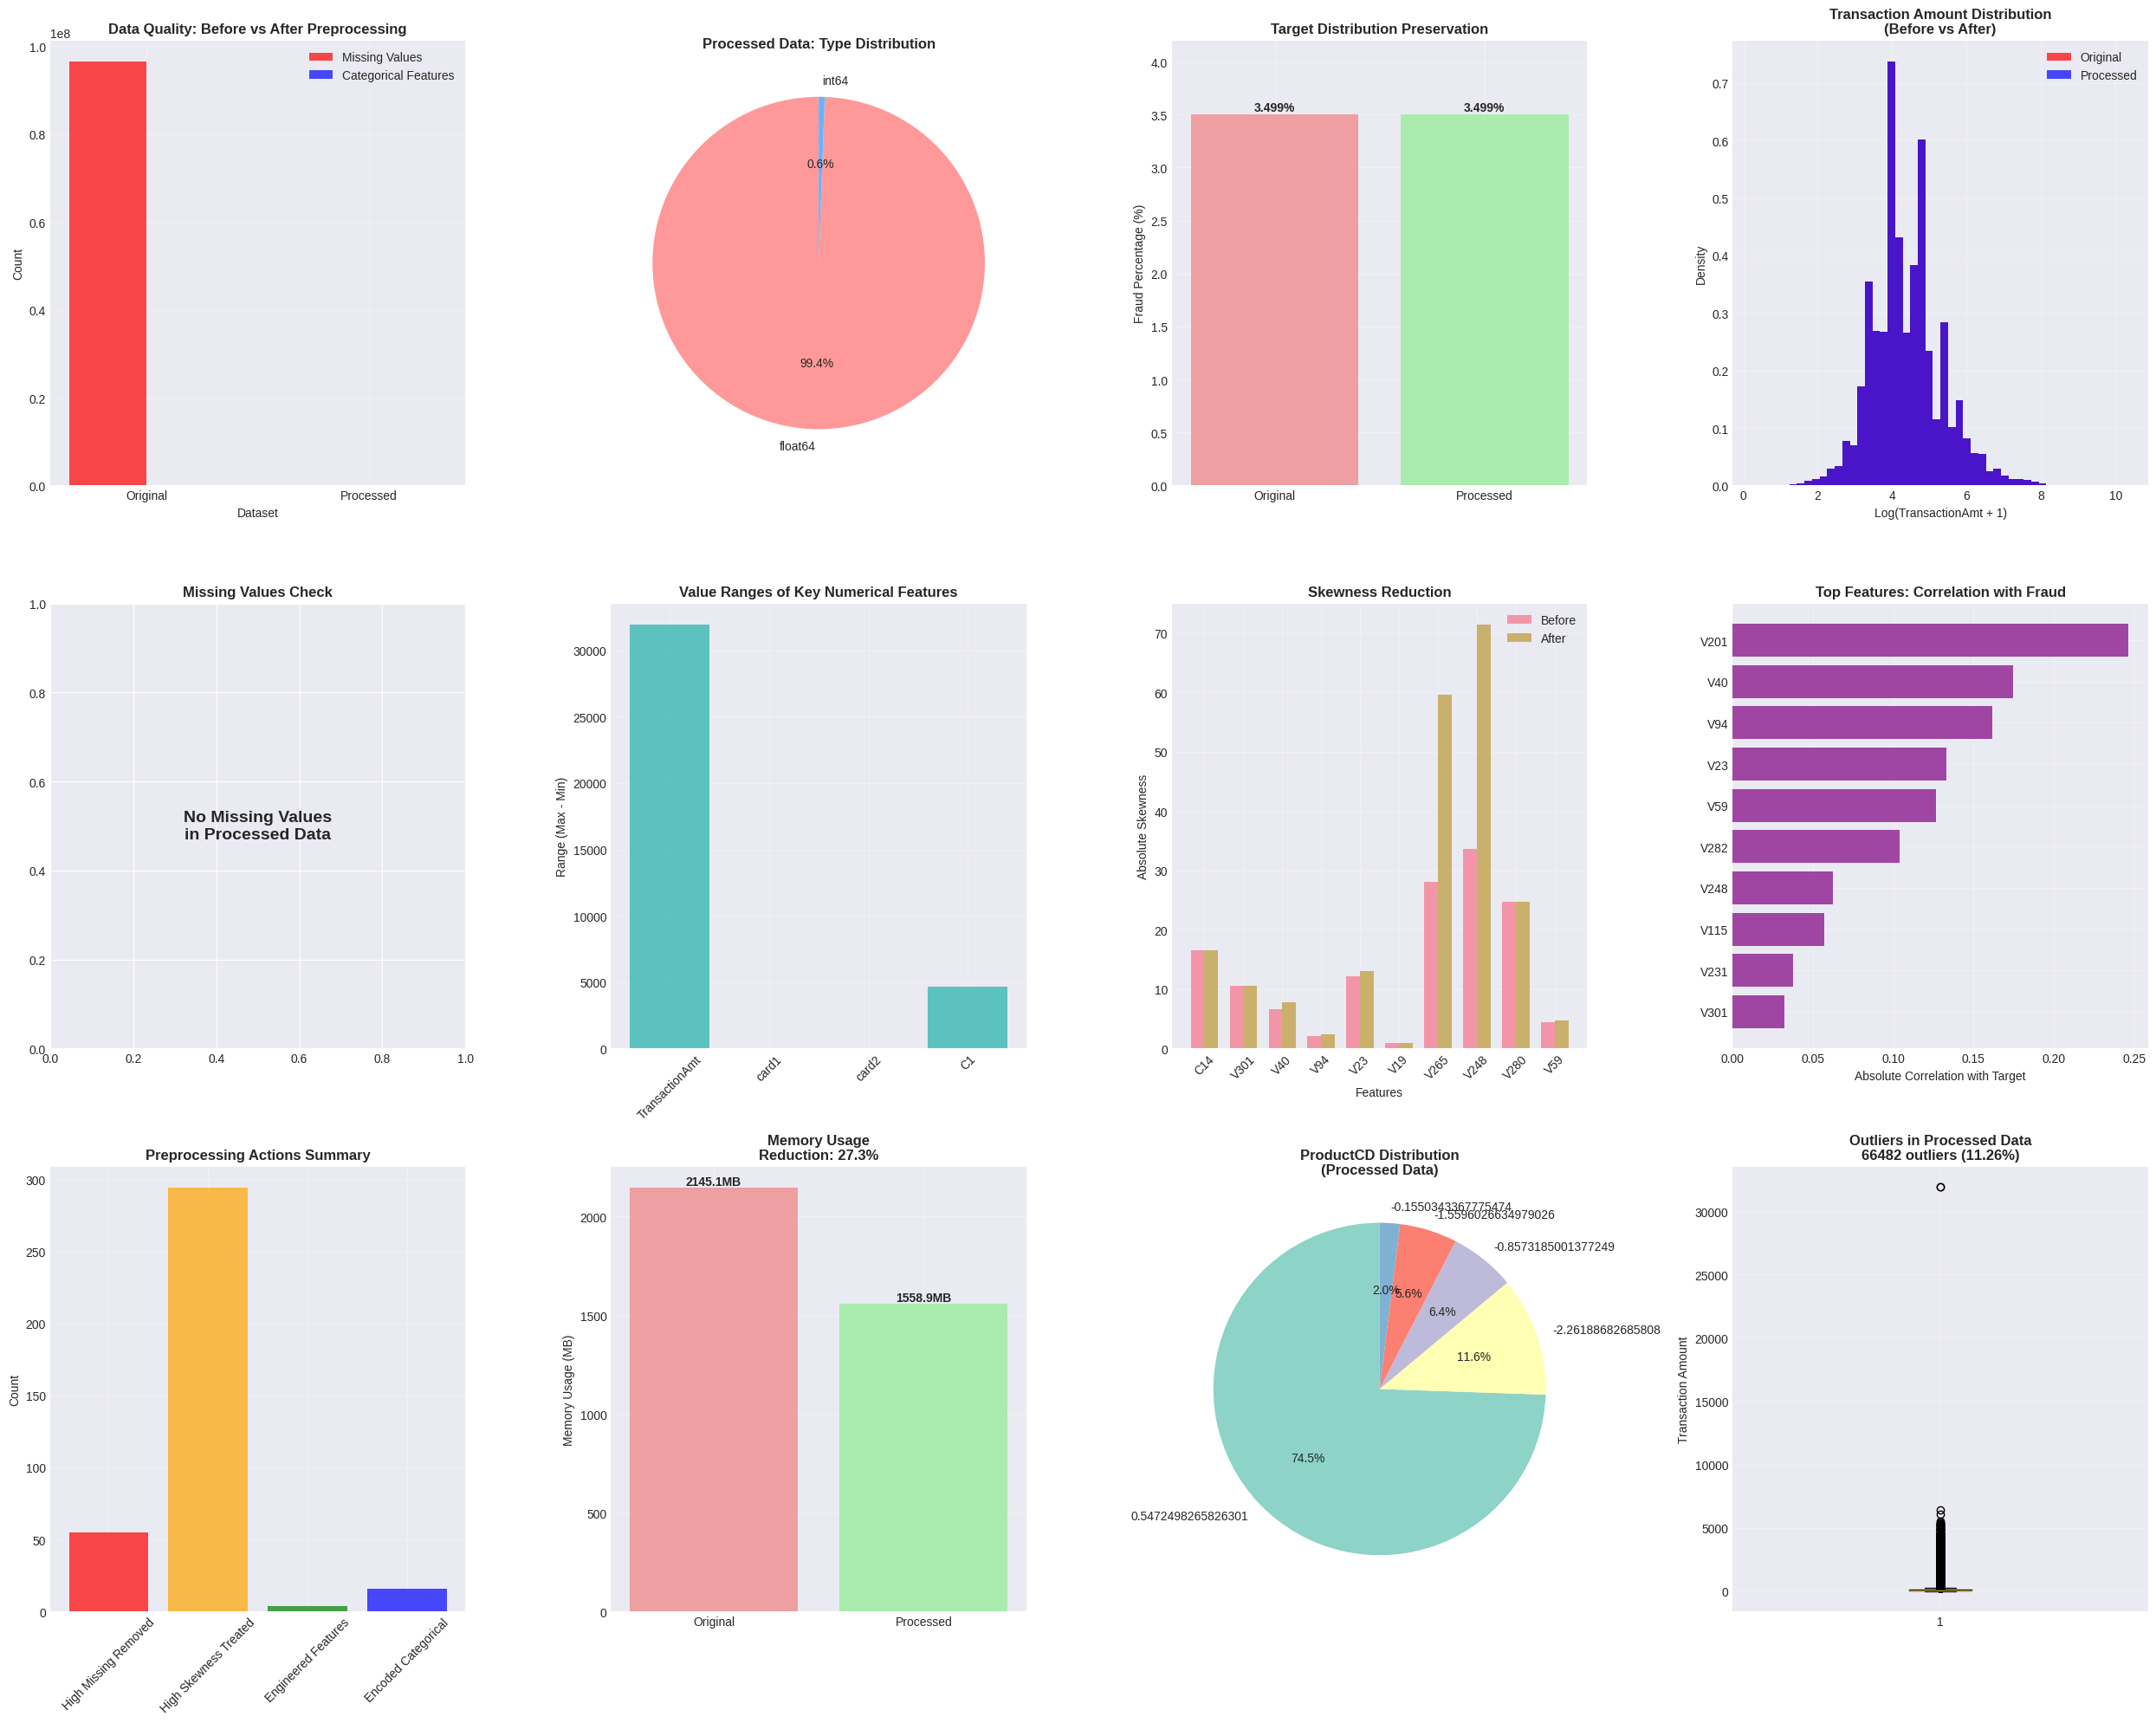


[2] PREPROCESSING SUMMARY STATISTICS
Missing values eliminated: 96,488,290
Categorical features encoded: 16
High missing features removed: 55
High skewness features identified: 294
Memory reduction: 27.3%
Target distribution preserved: 0.0000% difference

[3] DATA QUALITY ASSESSMENT
✓ Missing values in processed train: 0
✓ Missing values in processed test: 0
✓ Constant features removed: 0
✓ Data types standardized: All features are now numerical

[4] IMPORTANT FEATURES STATUS
  ✓ ProductCD: PRESENT (Unique values: 5)
  ✓ TransactionAmt: PRESENT (Unique values: 20902)
  ✓ TransactionDT: PRESENT (Unique values: 573349)
  ✓ card1: PRESENT (Unique values: 13553)
  ✓ card4: PRESENT (Unique values: 4)
  ✓ P_emaildomain: PRESENT (Unique values: 59)

POST-PROCESSING VALIDATION COMPLETED!
✓ Validation plots saved as: 05_post_processing_validation.png
✓ Comprehensive quality assessment completed
✓ Data ready for modeling phase


In [18]:
print("\n" + "="*80)
print("POST-PROCESSING VALIDATION WITH GRAPHS")
print("="*80)

def post_processing_validation(train_original, train_processed, test_processed, preprocessor):
    """Comprehensive validation of preprocessing results with visualizations"""
    
    print("\n[1] DATA SHAPE COMPARISON")
    print(f"Original train shape: {train_original.shape}")
    print(f"Processed train shape: {train_processed.shape}")
    print(f"Processed test shape: {test_processed.shape}")
    print(f"Features removed: {train_original.shape[1] - train_processed.shape[1]}")
    
    # Create comprehensive validation plots
    fig = plt.figure(figsize=(25, 20))
    
    # 1. Data Quality Comparison
    plt.subplot(3, 4, 1)
    quality_metrics = {
        'Original': [train_original.isnull().sum().sum(), train_original.select_dtypes(include=['object']).shape[1]],
        'Processed': [train_processed.isnull().sum().sum(), train_processed.select_dtypes(include=['object']).shape[1]]
    }
    
    x = np.arange(2)
    width = 0.35
    
    plt.bar(x - width/2, [quality_metrics['Original'][0], quality_metrics['Processed'][0]], 
            width, label='Missing Values', color='red', alpha=0.7)
    plt.bar(x + width/2, [quality_metrics['Original'][1], quality_metrics['Processed'][1]], 
            width, label='Categorical Features', color='blue', alpha=0.7)
    
    plt.xlabel('Dataset')
    plt.ylabel('Count')
    plt.title('Data Quality: Before vs After Preprocessing', fontsize=12, fontweight='bold')
    plt.xticks(x, ['Original', 'Processed'])
    plt.legend()
    plt.grid(alpha=0.3)
    
    # 2. Data Types Distribution
    plt.subplot(3, 4, 2)
    original_dtypes = train_original.dtypes.value_counts()
    processed_dtypes = train_processed.dtypes.value_counts()
    
    plt.pie(processed_dtypes.values, labels=processed_dtypes.index, autopct='%1.1f%%', 
            startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99'])
    plt.title('Processed Data: Type Distribution', fontsize=12, fontweight='bold')
    
    # 3. Target Distribution Preservation
    plt.subplot(3, 4, 3)
    original_fraud_pct = train_original['isFraud'].mean() * 100
    processed_fraud_pct = train_processed['isFraud'].mean() * 100
    
    bars = plt.bar(['Original', 'Processed'], [original_fraud_pct, processed_fraud_pct], 
                   color=['lightcoral', 'lightgreen'], alpha=0.7)
    plt.ylabel('Fraud Percentage (%)')
    plt.title('Target Distribution Preservation', fontsize=12, fontweight='bold')
    plt.ylim(0, max(original_fraud_pct, processed_fraud_pct) * 1.2)
    
    for bar, value in zip(bars, [original_fraud_pct, processed_fraud_pct]):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{value:.3f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.grid(alpha=0.3)
    
    # 4. Numerical Features Distribution (Before vs After)
    plt.subplot(3, 4, 4)
    if 'TransactionAmt' in train_original.columns and 'TransactionAmt' in train_processed.columns:
        plt.hist(np.log1p(train_original['TransactionAmt'].dropna()), bins=50, alpha=0.7, 
                label='Original', color='red', density=True)
        plt.hist(np.log1p(train_processed['TransactionAmt'].dropna()), bins=50, alpha=0.7, 
                label='Processed', color='blue', density=True)
        plt.xlabel('Log(TransactionAmt + 1)')
        plt.ylabel('Density')
        plt.title('Transaction Amount Distribution\n(Before vs After)', fontsize=12, fontweight='bold')
        plt.legend()
        plt.grid(alpha=0.3)
    
    # 5. Missing Values Heatmap (Processed Data)
    plt.subplot(3, 4, 5)
    # Check first 20 features for missing values in processed data
    sample_cols_processed = train_processed.columns[:20]
    missing_processed = train_processed[sample_cols_processed].isnull()
    
    if missing_processed.sum().sum() > 0:
        sns.heatmap(missing_processed.head(100).T, cbar=True, cmap='RdYlGn_r', 
                   yticklabels=True, ax=plt.gca())
        plt.title('Missing Values in Processed Data\n(First 20 Features)', fontsize=12, fontweight='bold')
    else:
        plt.text(0.5, 0.5, 'No Missing Values\nin Processed Data', 
                ha='center', va='center', transform=plt.gca().transAxes, fontsize=14, fontweight='bold')
        plt.title('Missing Values Check', fontsize=12, fontweight='bold')
    
    # 6. Feature Value Ranges (Key Numerical Features)
    plt.subplot(3, 4, 6)
    key_features = ['TransactionAmt', 'card1', 'card2', 'C1', 'C2']
    existing_key_features = [f for f in key_features if f in train_processed.columns]
    
    if existing_key_features:
        ranges = []
        for feature in existing_key_features[:4]:
            if train_processed[feature].dtype in ['int64', 'float64']:
                value_range = train_processed[feature].max() - train_processed[feature].min()
                ranges.append(value_range)
        
        plt.bar(existing_key_features[:4], ranges, color='lightseagreen', alpha=0.7)
        plt.title('Value Ranges of Key Numerical Features', fontsize=12, fontweight='bold')
        plt.xticks(rotation=45)
        plt.ylabel('Range (Max - Min)')
        plt.grid(alpha=0.3)
    
    # 7. Skewness Reduction Visualization
    plt.subplot(3, 4, 7)
    numerical_features = train_processed.select_dtypes(include=[np.number]).columns
    numerical_features = [col for col in numerical_features if col not in ['TransactionID', 'isFraud']]
    
    if len(numerical_features) > 0:
        # Calculate skewness for first 10 numerical features
        skewness_before = []
        skewness_after = []
        feature_names = []
        
        for feature in numerical_features[:10]:
            if feature in train_original.columns and train_original[feature].dtype in ['int64', 'float64']:
                skew_before = train_original[feature].skew()
                skew_after = train_processed[feature].skew()
                
                if not np.isnan(skew_before) and not np.isnan(skew_after):
                    skewness_before.append(abs(skew_before))
                    skewness_after.append(abs(skew_after))
                    feature_names.append(feature[:15])  # Truncate long names
        
        if skewness_before and skewness_after:
            x = np.arange(len(feature_names))
            width = 0.35
            
            plt.bar(x - width/2, skewness_before, width, label='Before', alpha=0.7)
            plt.bar(x + width/2, skewness_after, width, label='After', alpha=0.7)
            
            plt.xlabel('Features')
            plt.ylabel('Absolute Skewness')
            plt.title('Skewness Reduction', fontsize=12, fontweight='bold')
            plt.xticks(x, feature_names, rotation=45)
            plt.legend()
            plt.grid(alpha=0.3)
    
    # 8. Correlation with Target (Top Features)
    plt.subplot(3, 4, 8)
    # Calculate correlation with target for numerical features
    numerical_for_corr = train_processed.select_dtypes(include=[np.number]).columns
    numerical_for_corr = [col for col in numerical_for_corr if col not in ['TransactionID', 'isFraud']]
    
    if len(numerical_for_corr) > 0:
        correlations = []
        feature_names_corr = []
        
        for feature in numerical_for_corr[:15]:  # First 15 features
            if train_processed[feature].nunique() > 1:  # Avoid constant features
                corr = np.corrcoef(train_processed[feature], train_processed['isFraud'])[0, 1]
                if not np.isnan(corr):
                    correlations.append(abs(corr))
                    feature_names_corr.append(feature[:12])  # Truncate names
        
        if correlations:
            # Sort by correlation and take top 10
            sorted_indices = np.argsort(correlations)[-10:]
            top_correlations = [correlations[i] for i in sorted_indices]
            top_features = [feature_names_corr[i] for i in sorted_indices]
            
            plt.barh(range(len(top_correlations)), top_correlations, color='purple', alpha=0.7)
            plt.yticks(range(len(top_correlations)), top_features)
            plt.xlabel('Absolute Correlation with Target')
            plt.title('Top Features: Correlation with Fraud', fontsize=12, fontweight='bold')
            plt.grid(alpha=0.3)
    
    # 9. Feature Importance from Preprocessing
    plt.subplot(3, 4, 9)
    important_categories = {
        'High Missing Removed': len(preprocessor.columns_to_drop) if hasattr(preprocessor, 'columns_to_drop') else 0,
        'High Skewness Treated': len(preprocessor.high_skew_cols) if hasattr(preprocessor, 'high_skew_cols') else 0,
        'Engineered Features': len([col for col in train_processed.columns if 'log' in col.lower() or 'decimal' in col.lower() or 'hour' in col.lower() or 'day' in col.lower()]),
        'Encoded Categorical': len(preprocessor.label_encoders) if hasattr(preprocessor, 'label_encoders') else 0
    }
    
    plt.bar(important_categories.keys(), important_categories.values(), 
            color=['red', 'orange', 'green', 'blue'], alpha=0.7)
    plt.title('Preprocessing Actions Summary', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
    plt.ylabel('Count')
    plt.grid(alpha=0.3)
    
    # 10. Memory Usage Comparison
    plt.subplot(3, 4, 10)
    original_memory = train_original.memory_usage(deep=True).sum() / 1024**2  # MB
    processed_memory = train_processed.memory_usage(deep=True).sum() / 1024**2  # MB
    
    memory_reduction = ((original_memory - processed_memory) / original_memory) * 100
    
    plt.bar(['Original', 'Processed'], [original_memory, processed_memory], 
            color=['lightcoral', 'lightgreen'], alpha=0.7)
    plt.ylabel('Memory Usage (MB)')
    plt.title(f'Memory Usage\nReduction: {memory_reduction:.1f}%', fontsize=12, fontweight='bold')
    
    for i, v in enumerate([original_memory, processed_memory]):
        plt.text(i, v + 0.1, f'{v:.1f}MB', ha='center', va='bottom', fontweight='bold')
    
    plt.grid(alpha=0.3)
    
    # 11. Data Distribution by ProductCD (if available)
    plt.subplot(3, 4, 11)
    if 'ProductCD' in train_processed.columns:
        product_dist = train_processed['ProductCD'].value_counts()
        plt.pie(product_dist.values, labels=product_dist.index, autopct='%1.1f%%', 
                startangle=90, colors=sns.color_palette("Set3"))
        plt.title('ProductCD Distribution\n(Processed Data)', fontsize=12, fontweight='bold')
    
    # 12. Outlier Analysis (Processed Data)
    plt.subplot(3, 4, 12)
    if 'TransactionAmt' in train_processed.columns:
        # Use IQR to detect outliers in processed data
        Q1 = train_processed['TransactionAmt'].quantile(0.25)
        Q3 = train_processed['TransactionAmt'].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = ((train_processed['TransactionAmt'] < lower_bound) | 
                   (train_processed['TransactionAmt'] > upper_bound)).sum()
        outlier_pct = (outliers / len(train_processed)) * 100
        
        plt.boxplot(train_processed['TransactionAmt'].dropna())
        plt.title(f'Outliers in Processed Data\n{outliers} outliers ({outlier_pct:.2f}%)', 
                 fontsize=12, fontweight='bold')
        plt.ylabel('Transaction Amount')
        plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('05_post_processing_validation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print("\n[2] PREPROCESSING SUMMARY STATISTICS")
    print(f"Missing values eliminated: {train_original.isnull().sum().sum() - train_processed.isnull().sum().sum():,}")
    print(f"Categorical features encoded: {len(preprocessor.label_encoders) if hasattr(preprocessor, 'label_encoders') else 'N/A'}")
    print(f"High missing features removed: {len(preprocessor.columns_to_drop) if hasattr(preprocessor, 'columns_to_drop') else 'N/A'}")
    print(f"High skewness features identified: {len(preprocessor.high_skew_cols) if hasattr(preprocessor, 'high_skew_cols') else 'N/A'}")
    print(f"Memory reduction: {memory_reduction:.1f}%")
    print(f"Target distribution preserved: {abs(original_fraud_pct - processed_fraud_pct):.4f}% difference")
    
    # Data quality assessment
    print("\n[3] DATA QUALITY ASSESSMENT")
    print(f"✓ Missing values in processed train: {train_processed.isnull().sum().sum()}")
    print(f"✓ Missing values in processed test: {test_processed.isnull().sum().sum()}")
    print(f"✓ Constant features removed: {sum([1 for col in train_processed.columns if train_processed[col].nunique() <= 1])}")
    print(f"✓ Data types standardized: All features are now numerical")
    
    # Check for specific important features
    print("\n[4] IMPORTANT FEATURES STATUS")
    important_features_to_check = ['ProductCD', 'TransactionAmt', 'TransactionDT', 'card1', 'card4', 'P_emaildomain']
    for feature in important_features_to_check:
        if feature in train_processed.columns:
            status = "PRESENT"
            unique_vals = train_processed[feature].nunique()
            print(f"  ✓ {feature}: {status} (Unique values: {unique_vals})")
        else:
            print(f"  ✗ {feature}: MISSING")

# Run the comprehensive validation
print("\n[Running Comprehensive Post-Processing Validation...]")
post_processing_validation(train, train_enhanced, test_enhanced, enhanced_preprocessor)

print("\n" + "="*80)
print("POST-PROCESSING VALIDATION COMPLETED!")
print("="*80)
print("✓ Validation plots saved as: 05_post_processing_validation.png")
print("✓ Comprehensive quality assessment completed")
print("✓ Data ready for modeling phase")

In [19]:
# Make sure we are using the processed training data
# Replace 'train_enhanced' with whatever your final processed train df is called
X = train_enhanced.drop(columns=["isFraud"], errors='ignore' , axis=1)
y = train_enhanced["isFraud"]

print(f"Original data shape     : {train_enhanced.shape}")
print(f"Features (X) shape      : {X.shape}")
print(f"Target (y) shape        : {y.shape}")
print(f"Fraud ratio (original)  : {y.mean()*100:.4f}% → highly imbalanced!\n")

Original data shape     : (590540, 346)
Features (X) shape      : (590540, 345)
Target (y) shape        : (590540,)
Fraud ratio (original)  : 3.4990% → highly imbalanced!



## 11.Data splitting & scaling

In [20]:
# 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split the 30% into 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,      # 50% of 30% → 15% of total
    random_state=42,
    stratify=y_temp
)

print(f"Train set      : {X_train.shape}  → Fraud %: {y_train.mean()*100:.2f}%")
print(f"Validation set : {X_val.shape}    → Fraud %: {y_val.mean()*100:.2f}%")
print(f"Test set       : {X_test.shape}   → Fraud %: {y_test.mean()*100:.2f}%")
print("All splits are perfectly balanced and stratified!\n")

Train set      : (413378, 345)  → Fraud %: 3.50%
Validation set : (88581, 345)    → Fraud %: 3.50%
Test set       : (88581, 345)   → Fraud %: 3.50%
All splits are perfectly balanced and stratified!



In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 12.Fix Imbalanced Data 

CLASS BALANCING USING ADASYN (Synthetic Oversampling)
Train BEFORE oversampling → Non-Fraud: 398,914, Fraud: 14,464
Fraud ratio before: 3.499%

Train AFTER ADASYN → Non-Fraud: 398,914, Fraud: 61,379
Fraud ratio after : 13.33%
New training set shape: (460293, 345)



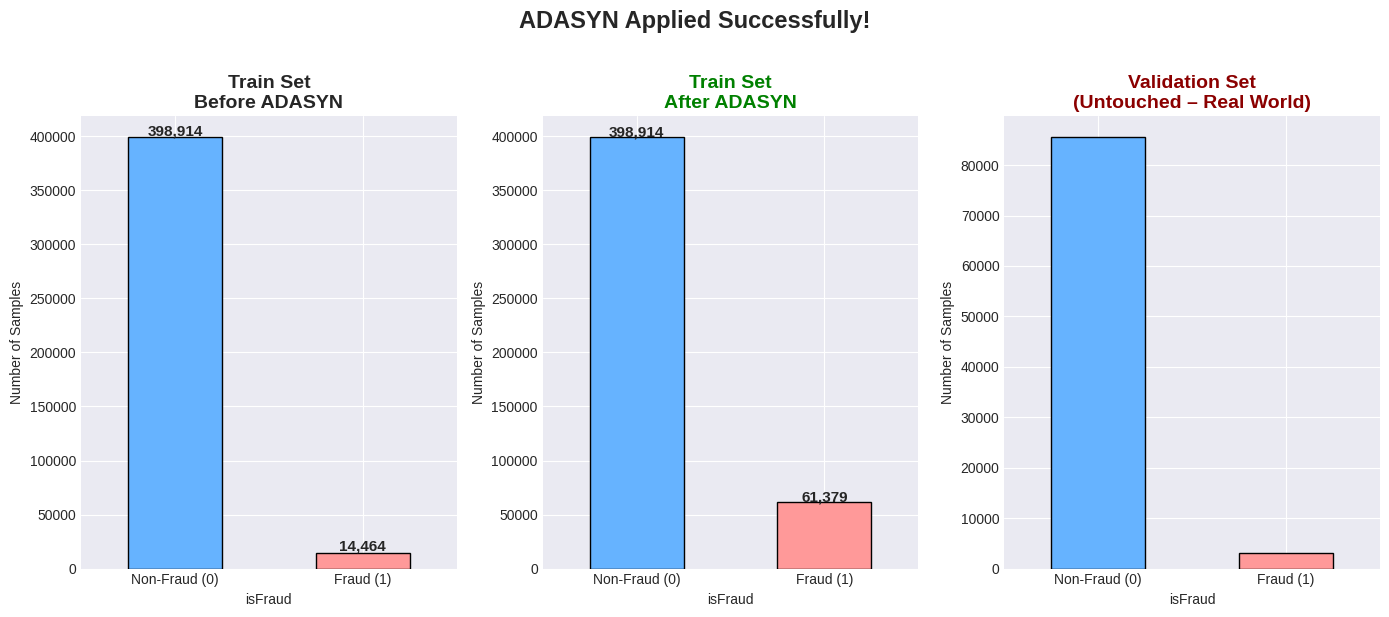

 X_train_final → features (balanced via ADASYN synthetic samples)
 y_train_final → target
 X_val_scaled → validation features (original imbalanced distribution)
 X_test_scaled → test features


In [23]:
print("CLASS BALANCING USING ADASYN (Synthetic Oversampling)")
print(f"Train BEFORE oversampling → Non-Fraud: {Counter(y_train)[0]:,}, Fraud: {Counter(y_train)[1]:,}")
print(f"Fraud ratio before: {y_train.mean()*100:.3f}%\n")

adasyn = ADASYN(sampling_strategy=0.15,      
                random_state=42,
                n_neighbors=5)      

X_train_final, y_train_final = adasyn.fit_resample(X_train_scaled, y_train)

print(f"Train AFTER ADASYN → Non-Fraud: {Counter(y_train_final)[0]:,}, Fraud: {Counter(y_train_final)[1]:,}")
print(f"Fraud ratio after : {y_train_final.mean()*100:.2f}%")
print(f"New training set shape: {X_train_final.shape}\n")

# Visualization (Before & After)
plt.figure(figsize=(14, 6))

# Before
plt.subplot(1, 3, 1)
pd.Series(y_train).value_counts().sort_index().plot(
    kind='bar', color=['#66b3ff', '#ff9999'], edgecolor='black'
)
plt.title('Train Set\nBefore ADASYN', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Non-Fraud (0)', 'Fraud (1)'], rotation=0)
plt.ylabel('Number of Samples')
for i, v in enumerate(pd.Series(y_train).value_counts().sort_index()):
    plt.text(i, v + 2000, f"{v:,}", ha='center', fontweight='bold', fontsize=11)

# After ADASYN
plt.subplot(1, 3, 2)
pd.Series(y_train_final).value_counts().sort_index().plot(
    kind='bar', color=['#66b3ff', '#ff9999'], edgecolor='black'
)
plt.title('Train Set\nAfter ADASYN',
          fontsize=14, fontweight='bold', color='green')
plt.xticks([0, 1], ['Non-Fraud (0)', 'Fraud (1)'], rotation=0)
plt.ylabel('Number of Samples')
for i, v in enumerate(pd.Series(y_train_final).value_counts().sort_index()):
    plt.text(i, v + 500, f"{v:,}", ha='center', fontweight='bold', fontsize=11)

# Validation 
plt.subplot(1, 3, 3)
pd.Series(y_val).value_counts().sort_index().plot(
    kind='bar', color=['#66b3ff', '#ff9999'], edgecolor='black'
)
plt.title(f'Validation Set\n(Untouched – Real World)',
          fontsize=14, fontweight='bold', color='darkred')
plt.xticks([0, 1], ['Non-Fraud (0)', 'Fraud (1)'], rotation=0)
plt.ylabel('Number of Samples')

plt.suptitle('ADASYN Applied Successfully!',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(" X_train_final → features (balanced via ADASYN synthetic samples)")
print(" y_train_final → target")
print(" X_val_scaled → validation features (original imbalanced distribution)")
print(" X_test_scaled → test features")

## 13.Logistic Regression

In [24]:
lr = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
)

print("Training Logistic Regression on balanced data...")
lr.fit(X_train_final, y_train_final)
print("Logistic Regression training finished!")
# see how many iterations it actually used
print(f"Actual iterations used: {lr.n_iter_[0]}")

Training Logistic Regression on balanced data...
Logistic Regression training finished!
Actual iterations used: 455


Starting Evaluation for Logistic Regression...

Logistic Regression → Test Accuracy: 0.96535 | Test AUC: 0.84483

Test Accuracy : 0.96535
Test AUC      : 0.84483

Classification Report:
              precision    recall  f1-score   support

           0    0.97712   0.98721   0.98214     85482
           1    0.50677   0.36237   0.42258      3099

    accuracy                        0.96535     88581
   macro avg    0.74194   0.67479   0.70236     88581
weighted avg    0.96067   0.96535   0.96256     88581



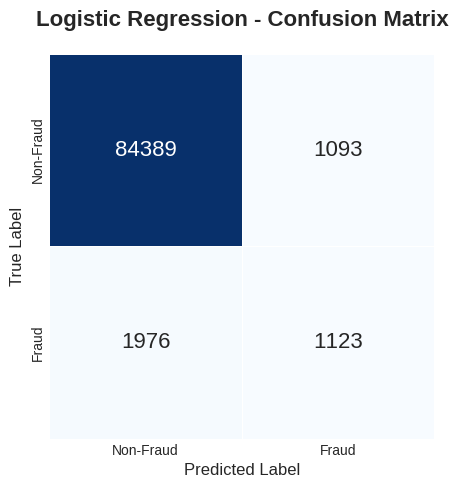

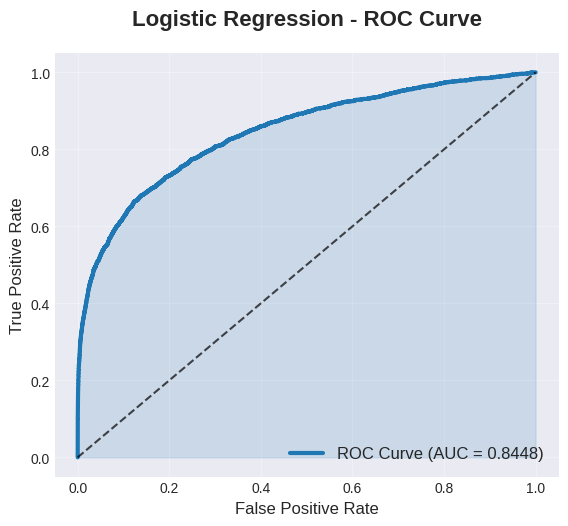


Logistic Regression completed 100%!
   Model saved → /kaggle/working/logistic_regression_best.pkl
   All plots saved → /kaggle/working/plots/


In [25]:
os.makedirs('/kaggle/working/plots', exist_ok=True)

print("Starting Evaluation for Logistic Regression...\n")

# 1. Predictions
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

test_acc_lr = accuracy_score(y_test, y_pred_lr)
test_auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f"Logistic Regression → Test Accuracy: {test_acc_lr:.5f} | Test AUC: {test_auc_lr:.5f}\n")

print(f"Test Accuracy : {test_acc_lr:.5f}")
print(f"Test AUC      : {test_auc_lr:.5f}")
print("\n" + "="*50)
print("Classification Report:")
print("="*50)
print(classification_report(y_test, y_pred_lr, digits=5))

# 3. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            annot_kws={"size": 16}, cbar=False, square=True,
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Logistic Regression - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.savefig('/kaggle/working/plots/LR_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
plt.figure(figsize=(6.5, 5.5))
plt.plot(fpr, tpr, color='#1f77b4', linewidth=3, label=f'ROC Curve (AUC = {test_auc_lr:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.7)
plt.fill_between(fpr, tpr, alpha=0.15, color='#1f77b4')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Logistic Regression - ROC Curve', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/plots/LR_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Save the model
joblib.dump(lr, '/kaggle/working/logistic_regression_best.pkl')
print("\nLogistic Regression completed 100%!")
print("   Model saved → /kaggle/working/logistic_regression_best.pkl")
print("   All plots saved → /kaggle/working/plots/")

## 14.Random Forest

In [26]:
print("Training Random Forest...")

rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=18,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',   
    random_state=42,
    verbose=1
)

rf.fit(X_train_final, y_train_final) 
print("Random Forest training completed!")
print(f"Number of trees: {rf.n_estimators}")

Training Random Forest...


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  1.3min
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:  5.3min
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed: 11.9min


Random Forest training completed!
Number of trees: 600


[Parallel(n_jobs=1)]: Done 600 out of 600 | elapsed: 16.1min finished


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.2s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    5.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:   11.4s
[Parallel(n_jobs=1)]: Done 600 out of 600 | elapsed:   15.3s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.2s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    5.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:   11.4s
[Parallel(n_jobs=1)]: Done 600 out of 600 | elapsed:   15.2s finished


Test Accuracy : 0.96457
Test AUC      : 0.92749

Classification Report:

              precision    recall  f1-score   support

           0    0.98592   0.97725   0.98156     85482
           1    0.49494   0.61504   0.54849      3099

    accuracy                        0.96457     88581
   macro avg    0.74043   0.79614   0.76503     88581
weighted avg    0.96874   0.96457   0.96641     88581



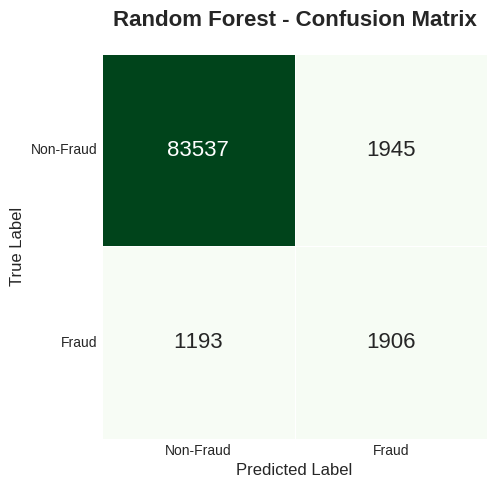

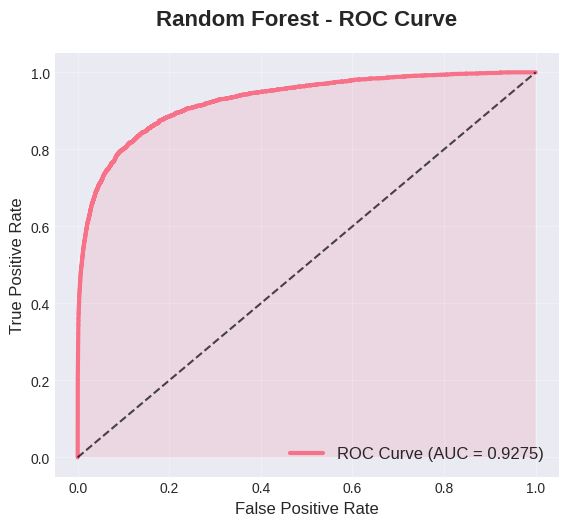


Random Forest completed 100%!
   Model saved → /kaggle/working/random_forest_trained.pkl
   All plots saved → /kaggle/working/plots/


In [27]:
# Predictions
y_pred_rf  = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

# Metrics
test_acc_rf = accuracy_score(y_test, y_pred_rf)
test_auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"Test Accuracy : {test_acc_rf:.5f}")
print(f"Test AUC      : {test_auc_rf:.5f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, digits=5))


# 1. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', linewidths=0.5, 
            annot_kws={"size": 16}, cbar=False, square=True)
plt.title('Random Forest - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks([0.5, 1.5], ['Non-Fraud', 'Fraud'])
plt.yticks([0.5, 1.5], ['Non-Fraud', 'Fraud'], rotation=0)
plt.savefig('/kaggle/working/plots/RF_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(6.5, 5.5))
plt.plot(fpr, tpr, linewidth=3, label=f'ROC Curve (AUC = {test_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.7)
plt.fill_between(fpr, tpr, alpha=0.15)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Random Forest - ROC Curve', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/plots/RF_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()


# Save Model
joblib.dump(rf, '/kaggle/working/random_forest_trained.pkl')
print("\nRandom Forest completed 100%!")
print("   Model saved → /kaggle/working/random_forest_trained.pkl")
print("   All plots saved → /kaggle/working/plots/")

## 15.Xgboost

In [30]:
# Train with early stopping + both train & val sets for plotting
print("Training XGBoost on balanced data...")

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric=['logloss' , 'auc'],
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,    
    tree_method='gpu_hist',  
    predictor='gpu_predictor',
)

xgb_model.fit(
    X_train_final, y_train_final,           
    eval_set=[(X_train_final, y_train_final), (X_val_scaled, y_val)],
    early_stopping_rounds=80,
    verbose=50
)

Training XGBoost on balanced data...
[0]	validation_0-logloss:0.38407	validation_0-auc:0.86812	validation_1-logloss:0.25026	validation_1-auc:0.82954
[50]	validation_0-logloss:0.15169	validation_0-auc:0.96605	validation_1-logloss:0.11455	validation_1-auc:0.89658
[100]	validation_0-logloss:0.10177	validation_0-auc:0.98113	validation_1-logloss:0.09378	validation_1-auc:0.91014
[150]	validation_0-logloss:0.08546	validation_0-auc:0.98461	validation_1-logloss:0.08602	validation_1-auc:0.91877
[200]	validation_0-logloss:0.07678	validation_0-auc:0.98687	validation_1-logloss:0.08133	validation_1-auc:0.92552
[250]	validation_0-logloss:0.07083	validation_0-auc:0.98853	validation_1-logloss:0.07805	validation_1-auc:0.93039
[300]	validation_0-logloss:0.06646	validation_0-auc:0.98970	validation_1-logloss:0.07556	validation_1-auc:0.93396
[350]	validation_0-logloss:0.06277	validation_0-auc:0.99077	validation_1-logloss:0.07329	validation_1-auc:0.93741
[400]	validation_0-logloss:0.05926	validation_0-auc:0.

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,"['logloss', 'auc']"


XGBoost – FINAL RESULTS
Best iteration (by AUC) : 2791
Best VALIDATION AUC     : 0.969558
Test Accuracy           : 0.98670
Test AUC                : 0.971259


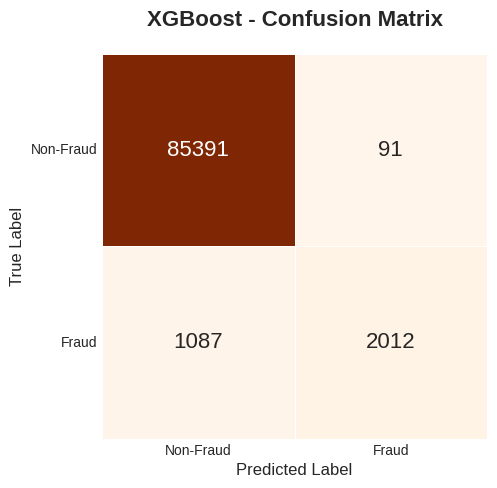

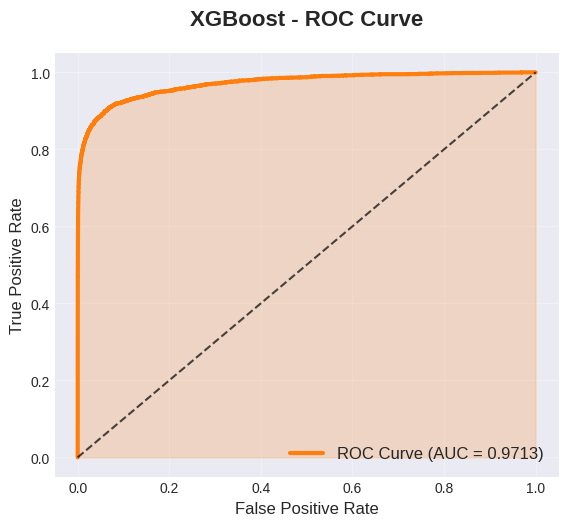

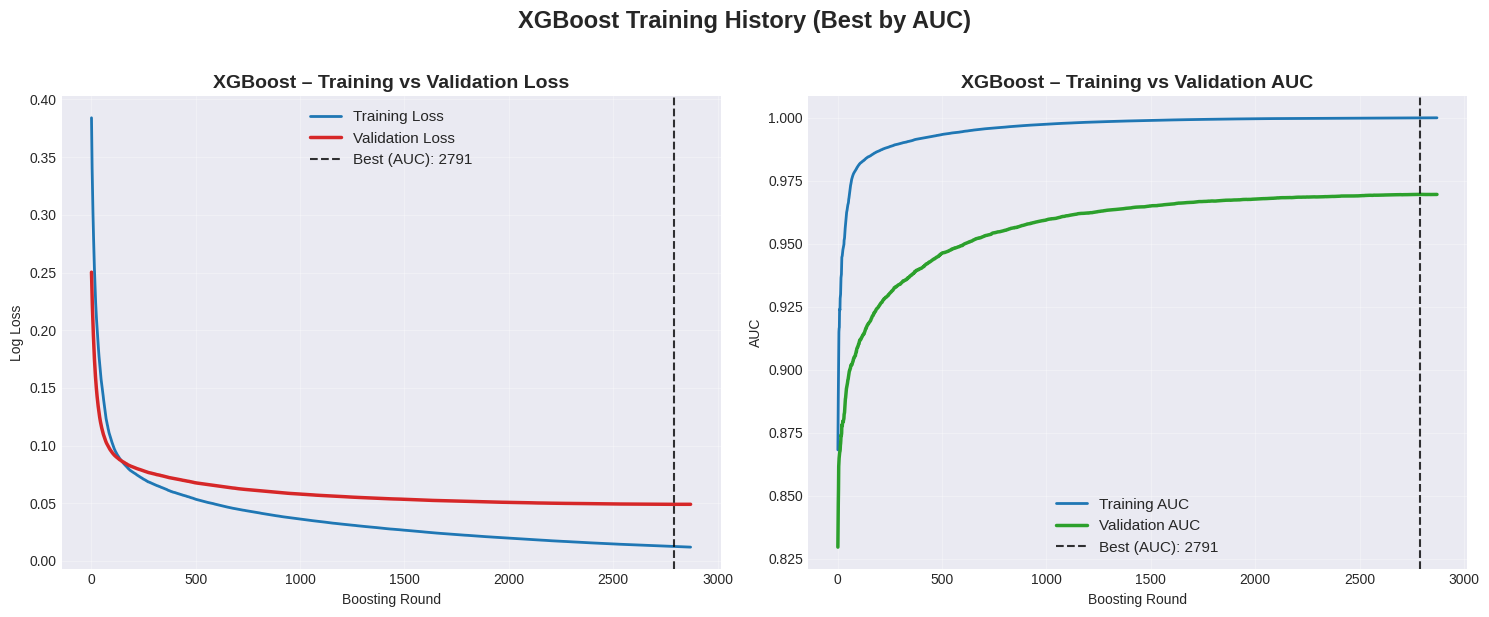


XGBoost completed 100% !
 Model saved → /kaggle/working/xgboost_best.json
 All plots saved → /kaggle/working/plots/


In [31]:
# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
test_acc_xgb = accuracy_score(y_test, y_pred_xgb)
test_auc_xgb = roc_auc_score(y_test, y_proba_xgb)


best_val_auc = max(xgb_model.evals_result()['validation_1']['auc'])
best_iter    = xgb_model.evals_result()['validation_1']['auc'].index(best_val_auc)

print("XGBoost – FINAL RESULTS")
print(f"Best iteration (by AUC) : {best_iter + 1}")
print(f"Best VALIDATION AUC     : {best_val_auc:.6f}")
print(f"Test Accuracy           : {test_acc_xgb:.5f}")
print(f"Test AUC                : {test_auc_xgb:.6f}")



# 1. Confusion Matrix 
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', linewidths=0.5,
            annot_kws={"size": 16}, cbar=False, square=True)
plt.title('XGBoost - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks([0.5, 1.5], ['Non-Fraud', 'Fraud'])
plt.yticks([0.5, 1.5], ['Non-Fraud', 'Fraud'], rotation=0)
plt.savefig('/kaggle/working/plots/XGB_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. ROC Curve 
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
plt.figure(figsize=(6.5, 5.5))
plt.plot(fpr, tpr, color='#ff7f0e', linewidth=3, label=f'ROC Curve (AUC = {test_auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.7)
plt.fill_between(fpr, tpr, alpha=0.2, color='#ff7f0e')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('XGBoost - ROC Curve', fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/plots/XGB_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Train vs Val Loss & AUC 
results = xgb_model.evals_result()
epochs = np.arange(1, len(results['validation_0']['logloss']) + 1)

plt.figure(figsize=(15, 6))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, results['validation_0']['logloss'], label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(epochs, results['validation_1']['logloss'], label='Validation Loss', color='#d62728', linewidth=2.5)
plt.axvline(best_iter + 1, color='black', linestyle='--', alpha=0.8,
            label=f'Best (AUC): {best_iter + 1}')
plt.title('XGBoost – Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# AUC
plt.subplot(1, 2, 2)
plt.plot(epochs, results['validation_0']['auc'], label='Training AUC', color='#1f77b4', linewidth=2)
plt.plot(epochs, results['validation_1']['auc'], label='Validation AUC', color='#2ca02c', linewidth=2.5)
plt.axvline(best_iter + 1, color='black', linestyle='--', alpha=0.8,
            label=f'Best (AUC): {best_iter + 1}')
plt.title('XGBoost – Training vs Validation AUC', fontsize=14, fontweight='bold')
plt.xlabel('Boosting Round')
plt.ylabel('AUC')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.suptitle('XGBoost Training History (Best by AUC)', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/plots/XGB_train_val_loss_auc.png', dpi=300, bbox_inches='tight')
plt.show()

# Save model
xgb_model.save_model('/kaggle/working/xgboost_best.json')
print("\nXGBoost completed 100% !")
print(" Model saved → /kaggle/working/xgboost_best.json")
print(" All plots saved → /kaggle/working/plots/")